In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR

### Load the data

In [2]:
df = pd.read_csv('train_data.csv')
df.head()

,MW,LogP,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,FractionCSP3,HalogenCount,SulfurCount,...,FP_2032,FP_2033,FP_2034,FP_2036,FP_2040,FP_2041,FP_2042,FP_2044,FP_2046,pIC50
0,432.480,4.11660,2.0,6.0,113.70,6.0,2.0,0.291667,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.619789
1,423.463,4.48660,2.0,4.0,70.56,5.0,2.0,0.291667,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.366532
2,432.480,4.11660,2.0,6.0,113.70,6.0,2.0,0.291667,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.508638
3,401.510,4.51682,2.0,4.0,70.56,5.0,2.0,0.320000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.420216
4,405.473,4.34750,2.0,4.0,70.56,5.0,2.0,0.291667,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.698970


#### Preparing Features and Target Variables and Checking Their Shapes

In [3]:
X = df.drop('pIC50',  axis=1)
Y = df['pIC50']

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

Shape of X: (13335, 1102)
Shape of Y: (13335,)


#### Splitting the data into train and validation (80:20)

Note: Feature selection (Variance Threshold + Correlation Filter) was already applied in the Data Preprocessing notebook. The `train_data.csv` loaded here contains only the pre-selected 1,102 features, no further feature removal is needed.

In [4]:
X_train_us, X_val_us, Y_train_us, Y_val_us = train_test_split(X, Y, test_size=0.2, random_state=42)

#### Scaling the data

SVR is sensitive to feature scale, so `StandardScaler` is applied to both features (`scaler_x`) and the target (`scaler_y`). The scaler is fit only on the training set and applied to val/test to prevent data leakage.

In [5]:
scaler_x = StandardScaler()
X_train = scaler_x.fit_transform(X_train_us)
X_val = scaler_x.transform(X_val_us)

scaler_y = StandardScaler()
Y_train = scaler_y.fit_transform(Y_train_us.values.reshape(-1, 1)).flatten()
Y_val = scaler_y.transform(Y_val_us.values.reshape(-1, 1)).flatten()

print("Shape of X_train:", X_train.shape, "Shape of Y_train:", Y_train.shape)
print("Shape of X_val:", X_val.shape, "Shape of Y_val:", Y_val.shape)

Shape of X_train: (10668, 1102) Shape of Y_train: (10668,)
Shape of X_val: (2667, 1102) Shape of Y_val: (2667,)


## Support Vector Regression(SVR)

In [6]:
svm_model = SVR(kernel='rbf', C=10, epsilon=0.1)
svm_model.fit(X_train, Y_train)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


Evaluates baseline SVR performance using RMSE, MAE, and R² on both training and validation sets. Predictions are inverse-transformed back to original pIC50 scale before computing metrics.

In [14]:
y_val_pred_scaled   = svm_model.predict(X_val)
y_train_pred_scaled = svm_model.predict(X_train)

y_val_pred   = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).flatten()
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()

svm_rmse_val   = np.sqrt(mean_squared_error(Y_val_us,   y_val_pred))
svm_rmse_train = np.sqrt(mean_squared_error(Y_train_us, y_train_pred))
svm_mae_val    = mean_absolute_error(Y_val_us, y_val_pred)
svm_r2_val     = r2_score(Y_val_us,   y_val_pred)
svm_r2_train   = r2_score(Y_train_us, y_train_pred)

print("Baseline SVR Performance (kernel=rbf, C=10, epsilon=0.1):")
print(f"  Train — RMSE: {svm_rmse_train:.4f}, R²: {svm_r2_train:.4f}")
print(f"  Val   — RMSE: {svm_rmse_val:.4f},  R²: {svm_r2_val:.4f},  MAE: {svm_mae_val:.4f}")
print(f"\nNote: Higher train R² vs val R² suggests overfitting: hyperparameter tuning needed.")


KeyboardInterrupt: 

The validation RMSE is higher than training RMSE, indicating overfitting with default settings. GridSearchCV with 5-fold cross-validation is applied to find optimal `C`, `epsilon`, and `gamma` values.

### Hyperparameter Tuning 

GridSearchCV with Cross-Validation


In [8]:
pipeline = Pipeline([
    ('svr', SVR(kernel='rbf'))
])
param_grid = {
    'svr__C':       [0.1, 1, 10, 100],
    'svr__epsilon': [0.01, 0.1, 0.5, 1.0],
    'svr__gamma':   ['scale', 0.01, 0.1, 1],
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    return_train_score=True,
    n_jobs=-1
)
grid_search.fit(X_train, Y_train)

print("Best Parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV R²: {grid_search.best_score_:.4f}")

Best Parameters:
  svr__C: 10
  svr__epsilon: 0.01
  svr__gamma: scale

Best CV R²: 0.7062


### Model Evaluation after Tuning: RMSE, MAE and R² Score Calculation

In [ ]:
best_svr_model = grid_search.best_estimator_

y_val_pred_scaled   = best_svr_model.predict(X_val)
y_train_pred_scaled = best_svr_model.predict(X_train)

y_val_pred   = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).flatten()
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()

best_svr_rmse_val   = np.sqrt(mean_squared_error(Y_val_us,   y_val_pred))
best_svr_rmse_train = np.sqrt(mean_squared_error(Y_train_us, y_train_pred))
best_svr_mae_val    = mean_absolute_error(Y_val_us, y_val_pred)
best_svr_r2_val     = r2_score(Y_val_us,   y_val_pred)
best_svr_r2_train   = r2_score(Y_train_us, y_train_pred)

print("Tuned SVR Performance:")
print(f"  Train_RMSE: {best_svr_rmse_train:.4f}, R²: {best_svr_r2_train:.4f}")
print(f"  Val_RMSE: {best_svr_rmse_val:.4f},  R²: {best_svr_r2_val:.4f},  MAE: {best_svr_mae_val:.4f}")

Tuned SVR Performance:
  Train — RMSE: 0.1175, R²: 0.9936
  Val   — RMSE: 0.7817,  R²: 0.7222,  MAE: 0.5615


## Test Data

In [10]:
df_test = pd.read_csv('test_data.csv')
X_test = df_test.drop('pIC50', axis=1)
Y_test = df_test['pIC50']

print("Shape of X_test:", X_test.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_test: (3651, 1102)
Shape of Y_test: (3651,)


The test set uses the same `scaler_x` and `scaler_y` fitted on training data. Predictions are inverse-transformed to pIC50 scale before computing metrics, consistent with how val metrics were calculated.

##### Feature selection was applied in preprocessing — test_data.csv already has matching columns

In [ ]:

X_test_scaled = scaler_x.transform(X_test)

y_test_pred_scaled = best_svr_model.predict(X_test_scaled)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()

test_rmse = np.sqrt(mean_squared_error(Y_test, y_test_pred))
test_mae  = mean_absolute_error(Y_test, y_test_pred)
test_r2   = r2_score(Y_test, y_test_pred)

print("Test Set Performance (scaffold-based split — chemically distinct molecules):")
print(f"  RMSE : {test_rmse:.4f}")
print(f"  MAE  : {test_mae:.4f}")
print(f"  R²   : {test_r2:.4f}")

Test Set Performance (scaffold-based split — chemically distinct molecules):
  RMSE : 0.9203
  MAE  : 0.6756
  R²   : 0.5972


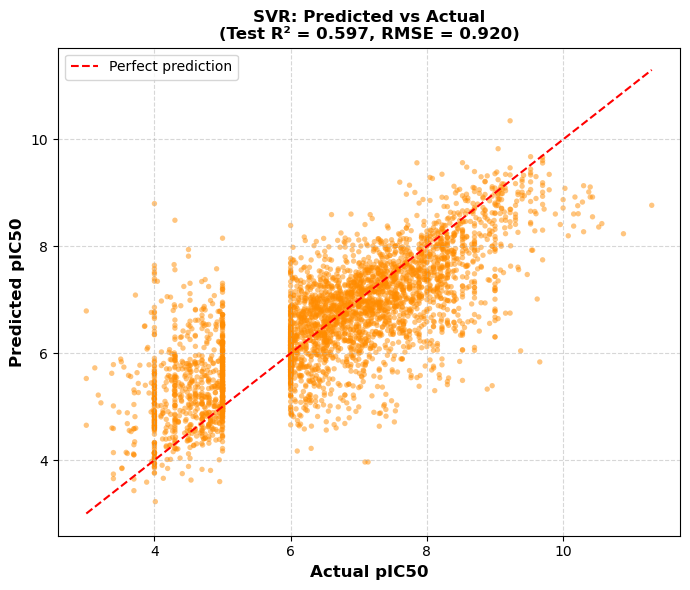

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(Y_test, y_test_pred, alpha=0.5, color='darkorange', edgecolors='none', s=15)
lims = [min(Y_test.min(), y_test_pred.min()), max(Y_test.max(), y_test_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual pIC50', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize=12, fontweight='bold')
ax.set_title(f'SVR: Predicted vs Actual\n(Test R² = {test_r2:.3f}, RMSE = {test_rmse:.3f})',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Observation (SVR Predicted vs Actual):**
- Points cluster more symmetrically around the diagonal compared to Random Forest, indicating better generalisation across the full pIC50 range.
- **Key difference from Random Forest:** SVR with an RBF kernel fits a continuous function in feature space and can predict values beyond the training range, it is not bounded by a leaf-node average. Random Forest, by contrast, cannot extrapolate beyond the min/max pIC50 seen during training, causing visible clipping at the extremes (as documented in the RF notebook). SVR does not suffer from this limitation.
- Scatter at the extremes (very low or very high pIC50) is still expected on a scaffold-based test set, as the model encounters chemically novel scaffolds not seen during training.


Saving the test RMSE and R² score for final comparison in the Results notebook.

In [13]:
def save_model_info(model_name, test_accuracy_rmse, r2 ):
    with open("model_info.txt", "a") as file:
        file.write(f"{model_name},{test_accuracy_rmse:.4f}, {r2:.4f}\n")

save_model_info("SVR", test_rmse, test_r2)

## Appendix

AI tools are being used to optimize some codes, below interactions are being passed to it:
1. Correct the code
2. Optimize the code